In [2]:

import numpy as np

from Kea.statistics.spectra import per_spectra, spectra_base, strfn_spectra
from Kea.statistics.statfunc import statfunc_base, strfn
from Kea.statistics import statistics_base
from Kea.utils import plotting, data_writer

import h5py as h5

import time

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plotting.modify_rc()

twopi = 2.*np.pi
L = twopi
N = 2048
D = 2
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]
dx = L/N
dk = twopi/L


In [3]:
def SmoothySpec(a,start=None,end=None,width=3):
   b=a.copy()
   if start is None: start = 0
   if end is None: end = len(a)
   for i in range(start,end):
      #b[i+1::][:-1] = 0.25*b[i::][:-2]+0.5*b[i+1::][:-1]+0.25*b[i::][2:]
      b[i+1:-1] = 0.25*b[i:-2] + 0.5*b[i+1:-1] + 0.25*b[i+2:]
   return b


In [4]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
def imshow_cbar(ar, fig, ax, ax_kwargs={}, cbar_kwargs={}, noticks=True, cbar=True):
    im = ax.imshow(ar, **ax_kwargs)
    if cbar:
        divider = make_axes_locatable(ax)
        # size='5%', pad=0.05
        if len(cbar_kwargs) == 0:
            cbar_kwargs = {'size': '5%', 'pad': 0.05}
        cax = divider.append_axes('right', **cbar_kwargs)
        fig.colorbar(im, cax=cax, orientation='vertical')
    if noticks:
        ax.set_xticks([])
        ax.set_yticks([])
    return im

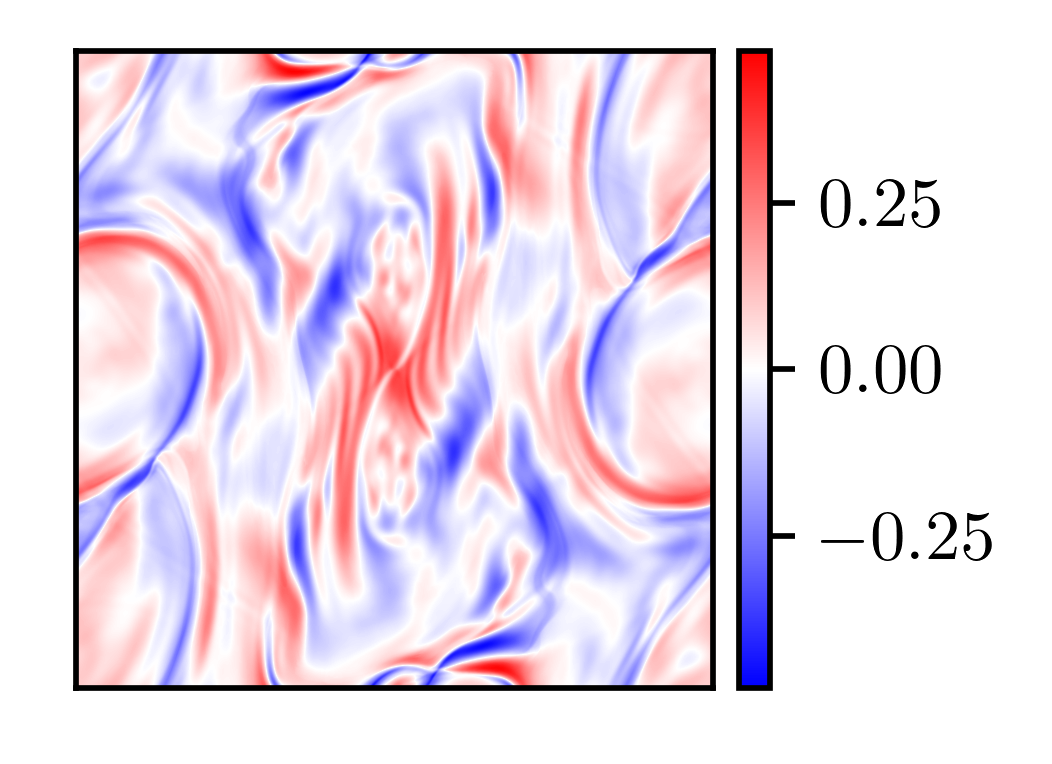

In [5]:

file0 = h5.File('SIMS_SF/2_2048_rho_e/in/T.Fr.h5', 'r')
field0 = np.array(file0['T.Fr'])

# file = h5.File('SF_TEST/2_512/out/SF_Grid_scalar_mine.h5', 'r')
# sf_f = np.array(file['SF_Grid_scalar2'])

file2 = h5.File('SIMS_SF/2_2048_rho_e/out/SF_Grid_scalar.h5', 'r')
sf_f2 = np.array(file2['SF_Grid_scalar2'])

# file3 = h5.File('SF_TEST/2_512/out/SF_Grid_scalar_mine_periodic.h5', 'r')
# sf_f3 = np.array(file3['SF_Grid_scalar2'])

fig, ax = plt.subplots(1, 1, figsize=(1.75, 1.75), dpi=512)
cmin, cmax = plotting.get_minmax(field0)
imshow_cbar(field0, fig, ax, ax_kwargs={'origin': 'lower', 'cmap': 'bwr', 'vmin': cmin, 'vmax': cmax})


/tmp/ipykernel_54872/4110303365.py:13: UserWarning: The following kwargs were not used by contour: 'linestyle'
  im2 = ax.contour(X, Y, sf_f2, np.linspace(cmin, cmax, 8), linewidths=0.5, linestyle=':', colors='black', vmin=cmin, vmax=cmax)


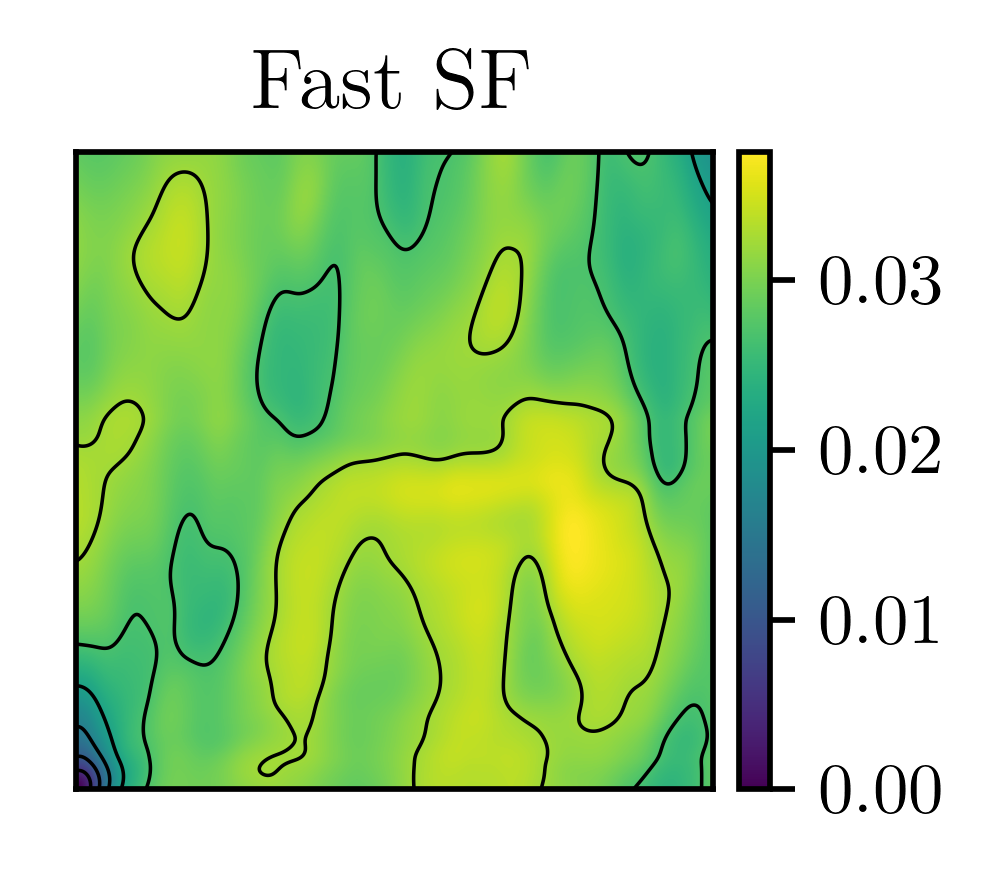

In [6]:

X, Y = np.meshgrid(np.arange(0, N//2, 1), np.arange(0, N//2, 1))

fig, ax = plt.subplots(1, 1, figsize=(1.75, 1.75), dpi=512)

cmin, cmax = np.min(sf_f2), np.max(sf_f2)


# imshow_cbar(sf_f[256:,256:].transpose(), fig, ax[0], ax_kwargs={'origin': 'lower', 'cmap': 'inferno', 'vmin': cmin, 'vmax': cmax}, cbar=False)
# ax[0].contour(X, Y, sf_f[256:,256:].transpose(), np.linspace(cmin, cmax, 8), linewidths=0.5, linestyle=':', colors='black', vmin=cmin, vmax=cmax)
# ax[0].set_title('Mine')

im = imshow_cbar(sf_f2, fig, ax, ax_kwargs={'origin': 'lower', 'cmap': 'viridis', 'vmin': cmin, 'vmax': cmax}, cbar=True)
im2 = ax.contour(X, Y, sf_f2, np.linspace(cmin, cmax, 8), linewidths=0.5, linestyle=':', colors='black', vmin=cmin, vmax=cmax)
ax.set_title('Fast SF')

# im = imshow_cbar(sf_f3[256:,256:], fig, ax[2], ax_kwargs={'origin': 'lower', 'cmap': 'inferno', 'vmin': cmin, 'vmax': cmax}, cbar=False)
# im2 = ax[2].contour(X, Y, sf_f3[256:,256:], np.linspace(cmin, cmax, 8), linewidths=0.5, linestyle=':', colors='black', vmin=cmin, vmax=cmax)
# ax[2].set_title('Periodic')


#fig.subplots_adjust(right=0.84)
#cbar_ax = fig.add_axes([0.85, 0.4525, 0.025, 0.1])
#cax = fig.colorbar(im, cax=cbar_ax)
#fig.colorbar(im2, cax=cbar_ax)

fig.subplots_adjust(hspace=0., wspace=0.1)

fig.savefig('SIMS_SF/2_2048_rho_e/out/SF_2d_plot.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
plt.show()


In [7]:

lvm_f = statfunc_base.get_lagvec_magnitude_array([n for n in grid_dims]) * dx
lvm_f = lvm_f[N//2:,N//2:]
l_f2, sf2_f2, w_f2 = statistics_base.bin_data(lvm_f, sf_f2, bin_func=np.nanmean, cut_excess=True, nan_small=False, min_bin=dx, max_bin=L/2., num_bins=N//8, bin_loc='center', log_space=True)

l_f2_t = l_f2[np.isfinite(sf2_f2)]
sf2_f2_t = sf2_f2[np.isfinite(sf2_f2)]

sf2_f2 = strfn_spectra.interpolate(l_f2_t, sf2_f2_t, l_f2)

sf2_f2_s = np.exp(SmoothySpec(np.log(sf2_f2)))
NN = 1
for _i in range(NN):
    sf2_f2_s = np.exp(SmoothySpec(np.log(sf2_f2_s), start=_i*N//NN))



/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))


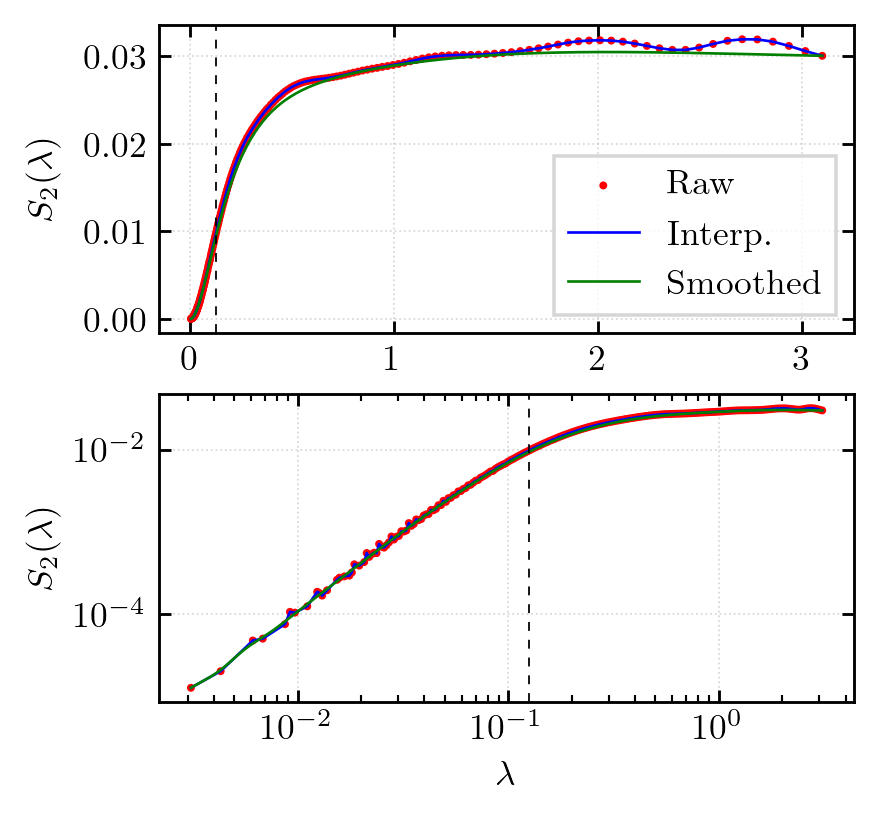

In [8]:

fig, ax = plt.subplots(2, 1, dpi=256, figsize=(3.5, 3.5))

for axx in [ax[0], ax[1]]:
    #axx.plot(l_f3, sf2_f3, linestyle='-', linewidth=0.75, color='black', label='Periodic')
    #axx.plot(l_f, sf2_f, linestyle='--', linewidth=0.75, color='green', label='Mine')
    axx.scatter(l_f2_t, sf2_f2_t, marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='none', label='Raw')
    axx.plot(l_f2, sf2_f2, linestyle='-', linewidth=0.75, color='blue', label='Interp.')
    axx.plot(l_f2, sf2_f2_s, linestyle='-', linewidth=0.75, color='green', label='Smoothed')
    #axx.plot(l_f2_full, sf2_f2_full, linestyle=(0,(5,3,1,3)), linewidth=0.75, color='red', label='fastSF full')

#ax[2].plot(l_f, sf2_f/sf2_f3, linestyle='--', linewidth=0.75, color='green', label='Mine')
#ax[2].plot(l_f2, sf2_f2/sf2_f3, linestyle=(0,(5,5)), linewidth=0.75, color='blue', label='fastSF')
#ax[2].plot(l_f2_full, sf2_f2_full/sf2_f3, linestyle=(0,(5,3,1,3)), linewidth=0.75, color='red', label='fastSF full')

for axx in ax:
    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')
    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
    axx.axvline(1./(8.*dk), color='black', linestyle=(0,(5,5)), linewidth=0.5)

ax[0].set_ylabel(r'$S_2(\lambda)$')
ax[1].set_ylabel(r'$S_2(\lambda)$')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[1].set_xlabel(r'$\lambda$')

ax[0].legend(fancybox=False)

fig.align_ylabels()


In [9]:
kD, fekD = per_spectra.modal_spectrum(field0, phys_dims=phys_dims)
fekD = fekD * (dk/twopi)**D
ko, feko, w = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims)

In [10]:
from Kea.statistics.spectra import strfn_spectra

def omni_spectrum(ell, sf2, phys_dims, grid_dims, a=1., b=1.):

    _dx = phys_dims[0]/grid_dims[0]
    _dk = 2.*np.pi/phys_dims[0]

    dS = np.gradient(sf2, _dx)
    dell = np.gradient(ell, _dx)

    fek = (ell)**2 * (dS/dell) * (1. / 2.) / a
    kk = b / ell

    kk = kk[::-1]
    fek = fek[::-1]

    kmin = np.nanmin(ko)
    kmax = np.nanmax(kk)
    fek = fek[kk > kmin]
    kk = kk[kk > kmin]

    fek = strfn_spectra.interpolate(kk, fek, ko[ko < kmax])
    return ko[ko < kmax], fek
    #return kk, fek

#k_f3, fek_f3 = omni_spectrum(l_f3, sf2_f3, phys_dims, grid_dims)
#k_f, fek_f = omni_spectrum(l_f, sf2_f, phys_dims, grid_dims)
k_f2, fek_f2 = omni_spectrum(l_f2, sf2_f2, phys_dims, grid_dims)
#k_f2_full, fek_f2_full = omni_spectrum(l_f2_full, sf2_f2_full, phys_dims, grid_dims)

k_f2_s, fek_f2_s = omni_spectrum(l_f2, sf2_f2_s, phys_dims, grid_dims)


/home/m/Documents/science_codes/Kea/Kea/statistics/spectra/strfn_spectra.py:32: RuntimeWarning: invalid value encountered in log10
  f_int = interp1d(np.log10(k_sf), np.log10(fek_sf), kind='linear', fill_value='extrapolate')


2*gamma(3/2 - beta/2)/(2**beta*gamma(beta/2 + 1/2))

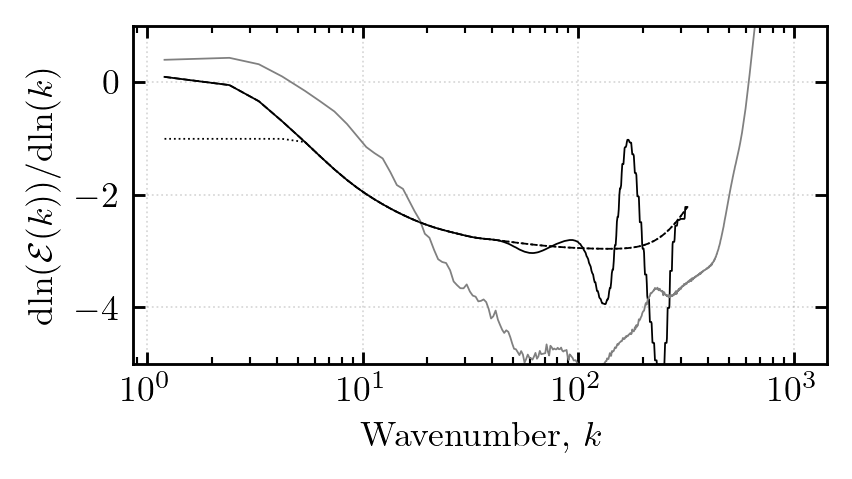

In [11]:

est_alpha = np.gradient(np.log(fek_f2_s), np.log(k_f2_s))

import sympy as sp

sp_beta = sp.symbols('beta', positive=True, real=True)
sp_D = sp.symbols('D', positive=True, real=True)
spec_bias = sp.S(2)*sp.S(2)**(-sp_beta) * (sp.gamma(sp_D/sp.S(2)) * sp.gamma((sp.S(3) - sp_beta) / sp.S(2))/sp.gamma(sp_D/sp.S(2) + sp_beta/sp.S(2) - sp.Rational(1,2)))
spec_bias = spec_bias.subs({sp_D: D})
display(spec_bias)

feko_s = np.exp(SmoothySpec(np.log(feko)))
for _ in range(5):
    feko_s = np.exp(SmoothySpec(np.log(feko_s)))
omni_alph = np.gradient(np.log(feko_s), np.log(ko))

fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)
ax.plot(k_f2_s, est_alpha, color='black', linestyle='-', linewidth=0.5)
ax.plot(ko, omni_alph, color='gray', linestyle='-', linewidth=0.5)
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
ax.set_xlabel('Wavenumber, $k$')
ax.set_ylabel(r'd$\ln({\mathcal{E}}(k))/$d$\ln(k)$')
ax.set_ylim((-5, 1))

for _ in range(100):
    est_alpha = SmoothySpec(est_alpha, start=40)
#est_alpha[50:] = est_alpha[50]
ax.plot(k_f2_s, est_alpha, color='black', linestyle='--', linewidth=0.5)


bias_factor = []
for _a in est_alpha:
    est_alpha[est_alpha > -1.01] = -1.01
    est_alpha[est_alpha < -2.99] = -2.99
    bias_factor.append(np.float64(spec_bias.subs({sp_beta: -_a}).evalf()))
bias_factor = np.array(bias_factor)

ax.plot(k_f2_s, est_alpha, color='black', linestyle=':', linewidth=0.5)


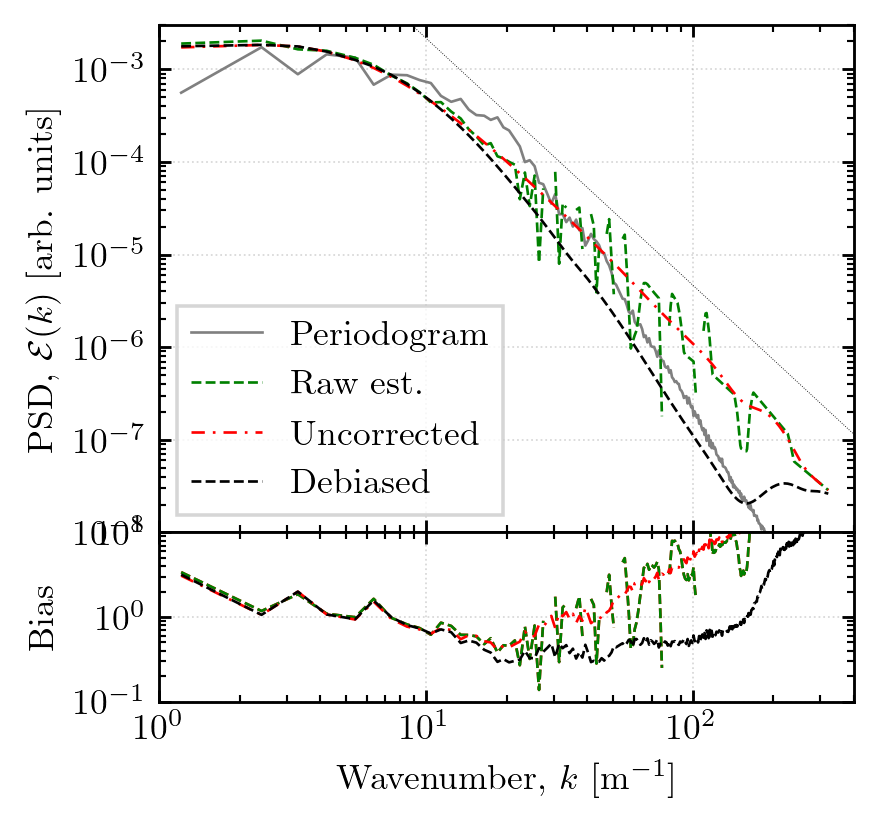

In [14]:

fig = plt.figure(1, dpi=256, figsize=(3.5, 3.5))
gs = mpl.gridspec.GridSpec(2, 1, height_ratios=[3, 1], figure=fig, hspace=0., wspace=0.05)

ax = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]

ax[0].plot(ko, feko, linestyle='-', linewidth=0.75, color='gray', label='Periodogram')
#ax[0].plot(ko, feko_s, linestyle='-', linewidth=0.75, color='gray', label='Periodogram')

#ax[0].plot(k_f3, fek_f3, linestyle=':', linewidth=0.75, color='red', label='Periodic')
#ax[0].plot(k_f, fek_f, linestyle='--', linewidth=0.75, color='green', label='Mine')
ax[0].plot(k_f2, fek_f2, linestyle='--', linewidth=0.75, color='green', label='Raw est.')
ax[0].plot(k_f2_s, fek_f2_s, linestyle=(0,(5,3,1,3)), linewidth=0.75, color='red', label='Uncorrected')
ax[0].plot(k_f2_s, fek_f2_s/bias_factor, linestyle='--', linewidth=0.75, color='black', label='Debiased')
#ax[0].plot(k_f2_full, fek_f2_full, linestyle=(0,(5,3,1,3)), linewidth=0.75, color='orange', label='fastSF full')

ax[0].plot(ko, ko**(-8./3.), linestyle=':', color='black', linewidth=0.25)

kmax = np.max(k_f2)
k_same = ko[ko <= kmax]
fek_same = feko[ko <= kmax]

#ax[1].plot(k_f3, fek_f3/fek_same, linestyle=':', linewidth=0.75, color='red', label='Periodic')
#ax[1].plot(k_f, fek_f/fek_same, linestyle='--', linewidth=0.75, color='green', label='Mine')
ax[1].plot(k_f2, fek_f2/fek_same, linestyle='--', linewidth=0.75, color='red', label='fastSF')
ax[1].plot(k_f2, fek_f2/fek_same, linestyle='--', linewidth=0.75, color='green', label='Raw est.')
ax[1].plot(k_f2_s, fek_f2_s/fek_same, linestyle=(0,(5,3,1,3)), linewidth=0.75, color='red', label='Uncorrected')
ax[1].plot(k_f2_s, fek_f2_s/bias_factor/fek_same, linestyle='--', linewidth=0.75, color='black', label='Debiased')
#ax[1].plot(k_f2_full, fek_f2_full/fek_same, linestyle=(0,(5,3,1,3)), linewidth=0.75, color='orange', label='fastSF full')

for axx in ax:
    axx.set_yscale('log')
    axx.set_xscale('log')
    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')
    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax[0].set_xlim((1, 400))
ax[1].set_xlim(ax[0].get_xlim())

ax[0].set_xticklabels([])

ax[0].legend(frameon=True, fancybox=False, loc='lower left')

ax[0].set_ylim((1e-8, 3e-3))
ax[1].set_ylim((1e-1, 1e1))

ax[0].set_ylabel(r'PSD, $\mathcal{E}(k)$ [arb. units]')
ax[1].set_xlabel(r'Wavenumber, $k$ [m$^{-1}$]')
ax[1].set_ylabel(r'Bias')

fig.align_ylabels()
